<a href="https://colab.research.google.com/github/Vhschulzg/vehicle-routing-problem-for-public-policy-reforestation-program/blob/main/Prueba_SV_02_09_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clustering y K-means


In [ ]:
!pip install pandas matplotlib openpyxl scikit-learn folium


In [ ]:
from google.colab import files
import pandas as pd

# Carga archivo de excel
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Lee Excel
df = pd.read_excel(filename)

# Valida columnas
required_columns = ['Location', 'Latitude', 'Longitude']
if not all(col in df.columns for col in required_columns):
    raise ValueError(f"Excel file must contain columns: {required_columns}")


df.head()


Saving Predios región B.xlsx to Predios región B (1).xlsx


,Location,Latitude,Longitude
0,1,18.803566,-96.475916
1,2,18.844700,-96.520000
2,3,18.810196,-96.533300
3,4,18.799087,-96.515647
4,5,18.814302,-96.537914


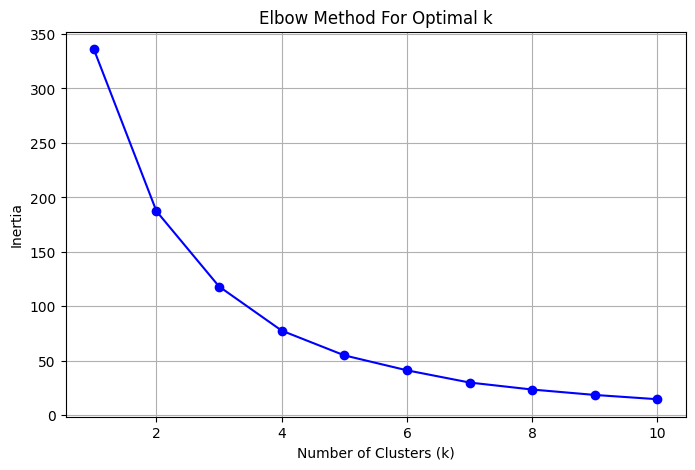

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Preparación de datos
X = df[['Latitude', 'Longitude']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Método del codo
inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Proyecta gráfica
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()


In [ ]:
# Entre el número óptimo de clusters (donde se observe el quiebre más abrupto)
n_clusters = int(input("Enter the number of clusters you want to use: "))


Enter the number of clusters you want to use: 4


In [ ]:
# Ejecuta KMeans
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

# Use the original df for assigning cluster labels
df['Cluster Assigned'] = kmeans.fit_predict(X_scaled)

# Muestra encabezados
df.head()

,Location,Latitude,Longitude,Cluster Assigned
0,1,18.803566,-96.475916,2
1,2,18.844700,-96.520000,1
2,3,18.810196,-96.533300,2
3,4,18.799087,-96.515647,2
4,5,18.814302,-96.537914,2


In [ ]:
# Guarda archivo de excel con los resultados de las agrupaciones
output_filename = 'clustered_locations.xlsx'
df.to_excel(output_filename, index=False)

# Descarga el archivo
files.download(output_filename)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import folium
from folium.plugins import MarkerCluster

#
map_center = [df['Latitude'].mean(), df['Longitude'].mean()]
cluster_map = folium.Map(location=map_center, zoom_start=6)

# Color de los clusters. Si son más de cinco grupos, agregar más colores siguiendo el patrón observado 'red', 'black'...
colors = [
    'red', 'blue', 'green', 'purple', 'orange',
]

# Agrega marcadores a clusters
marker_cluster = MarkerCluster().add_to(cluster_map)
for _, row in df.iterrows():
    cluster = int(row['Cluster Assigned'])
    color = colors[cluster % len(colors)]
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=5,
        popup=f"Location: {row['Location']}, Cluster: {cluster}",
        color=color,
        fill=True,
        fill_opacity=0.7
    ).add_to(marker_cluster)

# Muestra el mapa
cluster_map


In [ ]:
# Guarda el mapa como html
map_filename = "clustered_map.html"
cluster_map.save(map_filename)

# Descarga el archivo
files.download(map_filename)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Matriz de tiempo (crear una para cada cluster)


In [ ]:
!pip install googlemaps openpyxl matplotlib
import googlemaps
import openpyxl
import pandas as pd
import numpy as np

  Preparing metadata (setup.py) ... done
  Created wheel for googlemaps: filename=googlemaps-4.10.0-py3-none-any.whl size=40714 sha256=9c99fcd238449ef5e953a7c74911cc2ec8603d695226224d4b39161a6d7ce273
  Stored in directory: /root/.cache/pip/wheels/4c/6a/a7/bbc6f5c200032025ee655deb5e163ce8594fa05e67d973aad6
Successfully built googlemaps


In [ ]:
# Carga los datos de cada cluster. Debe incluir las columnas 'Latitude' y 'Longitude'
df = pd.read_excel('/content/Region B Cluster 0.xlsx')
locations = list(zip(df['Latitude'], df['Longitude']))


In [ ]:
!pip install -U googlemaps openpyxl matplotlib
import googlemaps
import openpyxl
import pandas as pd
import numpy as np
import pandas as pd
# si quieree cambiar de matriz de tiempo a distancia, debe cambiar 'duration' a 'distance' en la linea 41.
# cambio de mode de transporte en linea 22 y 53
def create_sub_matrix(origins, destinations, api_key):
    gmaps = googlemaps.Client(key=api_key)
    sub_matrix = np.zeros((len(origins), len(destinations)))

    for i, origin in enumerate(origins):
        distances = gmaps.distance_matrix(origins=[origin], destinations=destinations, mode="walking")
        for j, row in enumerate(distances['rows'][0]['elements']):
            if 'duration' in row:
                sub_matrix[i][j] = row['duration']['value']  # Duration in seconds
            else:
                print(f"Warning: No duration for origin {origin} to destination {destinations[j]}")
                sub_matrix[i][j] = np.nan  # Assign NaN or a large value to indicate a problem

    return sub_matrix

def create_time_matrix(locations, api_key, batch_size=19):
    n = len(locations)
    full_matrix = np.zeros((n, n))

    for i in range(0, n, batch_size):
        for j in range(0, n, batch_size):
            origins = locations[i:i+batch_size]
            destinations = locations[j:j+batch_size]
            sub_matrix = create_sub_matrix(origins, destinations, api_key)
            full_matrix[i:i+batch_size, j:j+batch_size] = sub_matrix

    return full_matrix

df = pd.read_excel('/content/Region B Cluster 0.xlsx')
locations = list(zip(df['Latitude'], df['Longitude']))

api_key = 'xxx'
time_matrix = create_time_matrix(locations, api_key, batch_size=10)

np.save('time_matrix Region B Cluster 0.npy', time_matrix)

print(time_matrix)

#
df = pd.DataFrame(time_matrix)

# Guarda CSV
csv_file_path = 'time_matrix Region B Cluster 0.csv'
df.to_csv(csv_file_path, index=False)  # Set index=False if you don't want row indices in your file


[[0.0000e+00 5.2610e+03 5.2640e+03 5.3400e+02 5.5110e+03 5.5110e+03
  5.5280e+03 4.8840e+03 4.4360e+03 1.2492e+04 3.2700e+03 4.4160e+03
  2.4470e+03 3.0430e+03 2.4420e+03 3.2420e+03 3.4410e+03 3.8680e+03
  3.6580e+03        nan        nan        nan        nan        nan
         nan        nan        nan        nan]
 [5.3180e+03 0.0000e+00 3.0000e+00 5.8510e+03 2.5000e+02 2.5000e+02
  2.6800e+02 3.6400e+02 8.0300e+02 1.7563e+04 8.5870e+03 1.1890e+03
  2.7870e+03 2.1980e+03 2.7930e+03 8.5600e+03 1.8050e+03 1.3940e+03
  8.9760e+03        nan        nan        nan        nan        nan
         nan        nan        nan        nan]
 [5.3210e+03 3.0000e+00 0.0000e+00 5.8540e+03 2.4700e+02 2.4700e+02
  2.6400e+02 3.6700e+02 8.0700e+02 1.7566e+04 8.5910e+03 1.1930e+03
  2.7900e+03 2.2010e+03 2.7960e+03 8.5630e+03 1.8080e+03 1.3970e+03
  8.9790e+03        nan        nan        nan        nan        nan
         nan        nan        nan        nan]
 [5.6700e+02 5.8280e+03 5.8310e+03 0.0000e+

# Definición de rutas y asignación de clusters a técnicos

In [ ]:
!pip install pulp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 91.2 MB/s eta 0:00:00


Resultados para Clúster0:
  Ruta: [0, 11, 6, 4, 5, 2, 1, 7, 8], Tiempo total: 6.43 horas
  Ruta: [0, 10, 15, 18, 3, 12, 13, 17], Tiempo total: 7.39 horas
  Ruta: [0, 16, 14, 9], Tiempo total: 7.34 horas
  Tiempo total para Clúster0: 21.16 horas



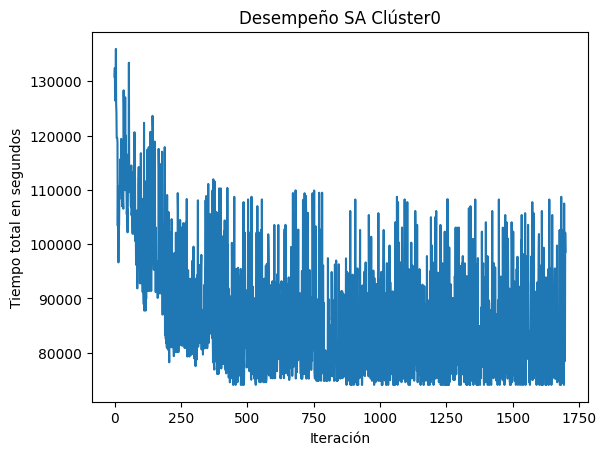

Resultados para Clúster1:
  Ruta: [0, 10, 1, 23, 11, 13, 22], Tiempo total: 6.51 horas
  Ruta: [0, 16, 19, 18, 2], Tiempo total: 7.35 horas
  Ruta: [0, 17], Tiempo total: 6.10 horas
  Ruta: [0, 6, 24, 8, 14, 3, 30], Tiempo total: 7.17 horas
  Ruta: [0, 38, 25, 42], Tiempo total: 5.97 horas
  Ruta: [0, 15, 12, 20, 7, 4, 9], Tiempo total: 6.74 horas
  Ruta: [0, 33, 41, 26, 36, 27, 28], Tiempo total: 7.68 horas
  Ruta: [0, 32, 29, 5], Tiempo total: 7.90 horas
  Ruta: [0, 40, 35, 37, 39, 43, 31, 34], Tiempo total: 7.06 horas
  Ruta: [0, 21], Tiempo total: 5.17 horas
  Tiempo total para Clúster1: 67.65 horas



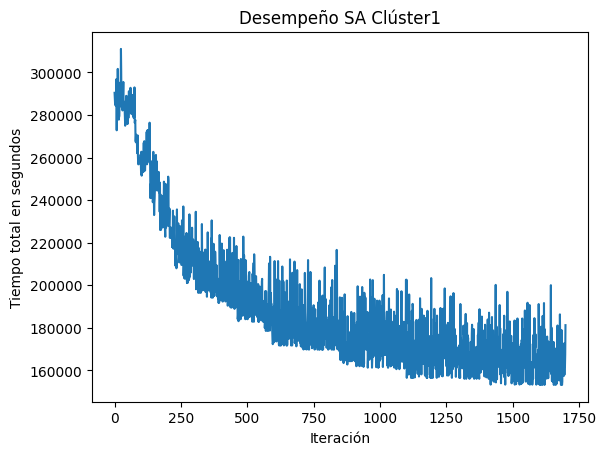

Resultados para Clúster2:
  Ruta: [0, 15, 9, 7, 8], Tiempo total: 7.89 horas
  Ruta: [0, 26, 13, 35], Tiempo total: 7.83 horas
  Ruta: [0, 10, 32, 22, 34], Tiempo total: 7.55 horas
  Ruta: [0, 33, 31, 30], Tiempo total: 6.94 horas
  Ruta: [0, 45, 51, 60, 47, 55], Tiempo total: 7.58 horas
  Ruta: [0, 62, 43, 44, 50, 59, 53], Tiempo total: 7.75 horas
  Ruta: [0, 58, 54, 48, 1], Tiempo total: 7.87 horas
  Ruta: [0, 57, 49, 40, 39, 41, 52], Tiempo total: 7.91 horas
  Ruta: [0, 46, 56, 2], Tiempo total: 6.98 horas
  Ruta: [0, 17, 16, 6], Tiempo total: 7.37 horas
  Ruta: [0, 37, 36], Tiempo total: 6.81 horas
  Ruta: [0, 42, 3, 29, 4], Tiempo total: 7.96 horas
  Ruta: [0, 28, 20, 5, 12], Tiempo total: 7.65 horas
  Ruta: [0, 61], Tiempo total: 7.29 horas
  Ruta: [0, 27, 24, 25, 23], Tiempo total: 7.73 horas
  Ruta: [0, 38, 14, 19], Tiempo total: 7.44 horas
  Ruta: [0, 18, 11, 21], Tiempo total: 7.42 horas
  Tiempo total para Clúster2: 127.95 horas



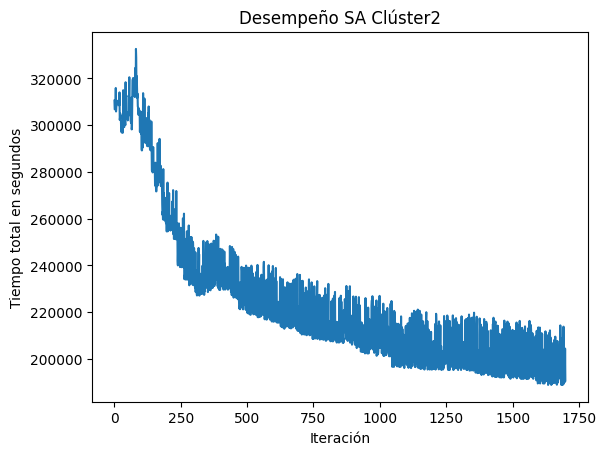

Resultados para Clúster3:
  Ruta: [0, 11, 41], Tiempo total: 6.37 horas
  Ruta: [0, 44], Tiempo total: 9.46 horas
  Ruta: [0, 6], Tiempo total: 7.80 horas
  Ruta: [0, 23, 24, 18, 9], Tiempo total: 7.43 horas
  Ruta: [0, 39, 3, 7, 8, 30, 36], Tiempo total: 7.65 horas
  Ruta: [0, 22, 5, 12, 43, 15, 13], Tiempo total: 7.99 horas
  Ruta: [0, 17, 21, 16, 34, 37], Tiempo total: 7.85 horas
  Ruta: [0, 14, 29, 1, 28], Tiempo total: 7.48 horas
  Ruta: [0, 27, 40, 31, 42, 10], Tiempo total: 7.61 horas
  Ruta: [0, 32, 33, 35, 20, 4], Tiempo total: 7.89 horas
  Ruta: [0, 2, 19, 26, 38, 25], Tiempo total: 7.87 horas
  Tiempo total para Clúster3: 85.40 horas



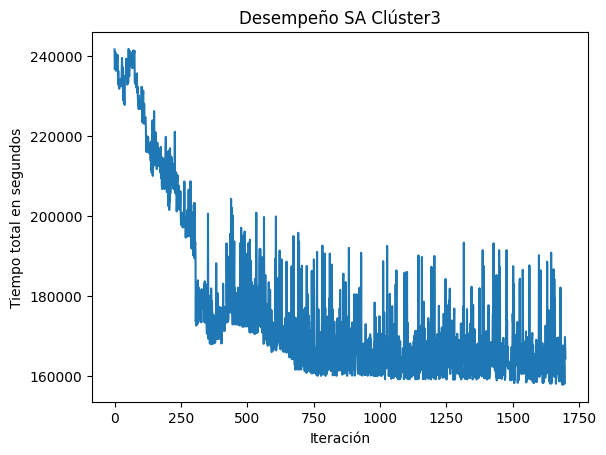

Asignación:
Clúster0 es asignado a Tec2
Clúster1 es asignado a Tec1
Clúster2 es asignado a Tec2
Clúster3 es asignado a Tec1
Tec1:
  Tiempo total: 153.05 horas
Tec2:
  Tiempo total: 149.12 horas


In [ ]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt
import pulp

# SA
def calculate_total_time(route, time_matrix, service_time):
    total_time = 0
    for i in range(1, len(route)):
        total_time += time_matrix[route[i-1]][route[i]]
    total_time += len(route) * service_time
    return total_time

def initial_solution(time_matrix, num_locations):
    route = list(range(1, num_locations))
    random.shuffle(route)
    route = [0] + route  # comienza en oficina
    return route

def get_neighbors_sa(current_route):
    if len(current_route) <= 3:
        return current_route
    a, b = random.sample(range(1, len(current_route)), 2)
    new_route = current_route[:]
    new_route[a], new_route[b] = new_route[b], new_route[a]
    return new_route

def simulated_annealing(time_matrix, service_time=1800, max_time_per_route=28800, temperature=5000, cooling_rate=0.995, min_temperature=1):
    num_locations = len(time_matrix)
    current_route = initial_solution(time_matrix, num_locations)
    current_cost = calculate_total_time(current_route, time_matrix, service_time)
    best_solution = current_route[:]
    best_cost = current_cost
    performance_data = []

    while temperature > min_temperature:
        new_route = get_neighbors_sa(current_route)
        new_cost = calculate_total_time(new_route, time_matrix, service_time)
        performance_data.append(new_cost)
        if new_cost < best_cost:
            best_solution, best_cost = new_route, new_cost
        if new_cost < current_cost or math.exp((current_cost - new_cost) / temperature) > random.random():
            current_route, current_cost = new_route, new_cost
        temperature *= cooling_rate

    routes = []
    temp_route = [0]
    for i in range(1, len(best_solution)):
        if calculate_total_time(temp_route + [best_solution[i]], time_matrix, service_time) <= max_time_per_route:
            temp_route.append(best_solution[i])
        else:
            routes.append(temp_route)
            temp_route = [0, best_solution[i]]
    routes.append(temp_route)

    return routes, performance_data

# MILP part
def assign_clusters_to_technicians(clusters):
    technicians = ['Tec1', 'Tec2']
    prob = pulp.LpProblem("Technician_Cluster_Assignment", pulp.LpMinimize)

    x = pulp.LpVariable.dicts("x", ((cluster, tech) for cluster in clusters for tech in technicians), cat='Binary')

    e_time = pulp.LpVariable("e_time", lowBound=0)

    prob += e_time

    for cluster in clusters:
        prob += pulp.lpSum(x[(cluster, tech)] for tech in technicians) == 1

    prob += e_time >= pulp.lpSum(clusters[cluster]['time'] * x[(cluster, 'Tec1')] for cluster in clusters) - \
            pulp.lpSum(clusters[cluster]['time'] * x[(cluster, 'Tec2')] for cluster in clusters)
    prob += e_time >= - (pulp.lpSum(clusters[cluster]['time'] * x[(cluster, 'Tec1')] for cluster in clusters) - \
                         pulp.lpSum(clusters[cluster]['time'] * x[(cluster, 'Tec2')] for cluster in clusters))

    status = prob.solve()

    technician_assignment = {}
    if status == pulp.LpStatusOptimal:
        for cluster in clusters:
            for tech in technicians:
                if pulp.value(x[(cluster, tech)]) == 1:
                    technician_assignment[cluster] = tech

    return technician_assignment

def main():
    #CArgar matrices
    time_matrices = {
        'Clúster0': np.load('/content/time_matrix region B Cluster 0.npy'),
        'Clúster1': np.load('/content/time_matrix region B Cluster 1.npy'),
        'Clúster2': np.load('/content/time_matrix region B Cluster 2.npy'),
        'Clúster3': np.load('/content/time_matrix region B Cluster 3.npy'),

    }

    clusters = {}

    # SA y agregar dinámicamente los resultados al diccionario
    for cluster_id, time_matrix in time_matrices.items():
        routes, performance_data = simulated_annealing(time_matrix)
        total_time = sum(calculate_total_time(route, time_matrix, 1800) for route in routes)
        clusters[cluster_id] = {
            'time': total_time / 3600  # convertir a horas
        }

        print(f"Resultados para {cluster_id}:")
        for route in routes:
            print(f"  Ruta: {route}, Tiempo total: {calculate_total_time(route, time_matrix, 1800) / 3600:.2f} horas")
        print(f"  Tiempo total para {cluster_id}: {total_time / 3600:.2f} horas\n")

        plt.plot(performance_data)
        plt.xlabel('Iteración')
        plt.ylabel('Tiempo total en segundos')
        plt.title(f'Desempeño SA {cluster_id}')
        plt.show()

    # asignación
    technician_assignment = assign_clusters_to_technicians(clusters)

    print("Asignación:")
    for cluster, tech in technician_assignment.items():
        print(f"{cluster} es asignado a {tech}")

    total_time_tech = {tech: 0 for tech in ['Tec1', 'Tec2']}

    for cluster, attributes in clusters.items():
        tech = technician_assignment[cluster]
        total_time_tech[tech] += attributes['time']

    for tech in ['Tec1', 'Tec2']:
        print(f"{tech}:")
        print(f"  Tiempo total: {total_time_tech[tech]:.2f} horas")

if __name__ == "__main__":
    main()

# Visualización de mapas